<a href="https://colab.research.google.com/github/DataScienceChallenge10/Hackathon_10_7_Dataset_B/blob/main/Hackathon_10_7_dataset_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing Neccessary Libraries

In [ ]:
# import Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Mounting Google colab

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Loading the dataset

In [ ]:
# Load the training dataset
train_df = pd.read_csv('/content/drive/MyDrive/2nd Year/Semester C/Hackathon/dataset_B_training.csv')

# Display the first 5 rows of the training DataFrame
train_df.head()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,h1n1_vaccine
0,1,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Female,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",2.0,1.0,science,0
1,2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Female,Below Poverty,Not Married,Own,Employed,Non-MSA,0.0,3.0,wholesale,0
2,3,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Female,"> $75,000",Not Married,Own,Employed,"MSA, Principle City",0.0,0.0,education,1
3,4,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Female,"<= $75,000, Above Poverty",Not Married,Rent,Not in Labor Force,Non-MSA,0.0,0.0,NaN,0
4,5,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Female,NaN,Not Married,NaN,Unemployed,Non-MSA,3.0,0.0,NaN,0


In [ ]:
# Load the testing dataset
test_df = pd.read_csv('/content/drive/MyDrive/2nd Year/Semester C/Hackathon/dataset_B_testing.csv')

# Display the first 5 rows of the testing DataFrame
test_df.head()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector
0,4757,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,White,Female,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,"MSA, Principle City",0.0,0.0,NaN
1,4758,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,White,Female,NaN,NaN,NaN,NaN,"MSA, Not Principle City",0.0,0.0,NaN
2,4759,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,White,Male,NaN,Married,Own,Not in Labor Force,"MSA, Principle City",1.0,0.0,NaN
3,4760,3.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,1.0,0.0,agriculture
4,4761,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,Non-MSA,0.0,0.0,wholesale


In [ ]:
# Get a concise summary of the training DataFrame
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4756 entries, 0 to 4755
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                4756 non-null   int64  
 1   h1n1_concern                 4741 non-null   float64
 2   h1n1_knowledge               4734 non-null   float64
 3   behavioral_antiviral_meds    4739 non-null   float64
 4   behavioral_avoidance         4729 non-null   float64
 5   behavioral_face_mask         4752 non-null   float64
 6   behavioral_wash_hands        4748 non-null   float64
 7   behavioral_large_gatherings  4747 non-null   float64
 8   behavioral_outside_home      4741 non-null   float64
 9   behavioral_touch_face        4736 non-null   float64
 10  doctor_recc_h1n1             4437 non-null   float64
 11  chronic_med_condition        4595 non-null   float64
 12  child_under_6_months         4622 non-null   float64
 13  health_worker     

In [ ]:
# Display descriptive statistics for numerical columns in the training DataFrame
train_df.describe()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,household_adults,household_children,h1n1_vaccine
count,4756.00000,4741.000000,4734.000000,4739.000000,4729.000000,4752.000000,4748.000000,4747.000000,4741.000000,4736.000000,...,4595.000000,4622.000000,4625.000000,2831.000000,4687.000000,4692.000000,4692.000000,4722.000000,4722.000000,4756.000000
mean,2378.50000,1.658933,1.307140,0.057396,0.740960,0.077652,0.842039,0.359385,0.341278,0.704814,...,0.314037,0.090437,0.141189,0.901801,3.965436,2.512361,2.412191,0.888818,0.542143,0.394029
std,1373.08327,0.892478,0.612811,0.232622,0.438154,0.267651,0.364743,0.479871,0.474189,0.456174,...,0.464182,0.286838,0.348254,0.297635,0.981737,1.336426,1.372509,0.755777,0.931243,0.488692
min,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,1189.75000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,4.000000,1.000000,1.000000,0.000000,0.000000,0.000000
50%,2378.50000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,4.000000,2.000000,2.000000,1.000000,0.000000,0.000000
75%,3567.25000,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,0.000000,1.000000,5.000000,4.000000,4.000000,1.000000,1.000000,1.000000
max,4756.00000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,5.000000,5.000000,5.000000,3.000000,3.000000,1.000000


In [ ]:
train_df.isnull().sum()

,0
respondent_id,0
h1n1_concern,15
h1n1_knowledge,22
behavioral_antiviral_meds,17
behavioral_avoidance,27
behavioral_face_mask,4
behavioral_wash_hands,8
behavioral_large_gatherings,9
behavioral_outside_home,15
behavioral_touch_face,20


In [ ]:
# Calculate the percentage of missing values for each column
missing_data = train_df.isnull().sum() / len(train_df) * 100
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

print("Percentage of missing values per column (only columns with missing values):\n")
display(missing_data)

Percentage of missing values per column (only columns with missing values):



,0
employment_sector,49.705635
health_insurance,40.475189
income_poverty,14.970563
doctor_recc_h1n1,6.707317
rent_or_own,6.623213
employment_status,4.941127
marital_status,4.751892
education,4.709840
chronic_med_condition,3.385198
child_under_6_months,2.817494


## Exploratory Data Analysis (EDA)

### 1. Target Variable Distribution (`h1n1_vaccine`)

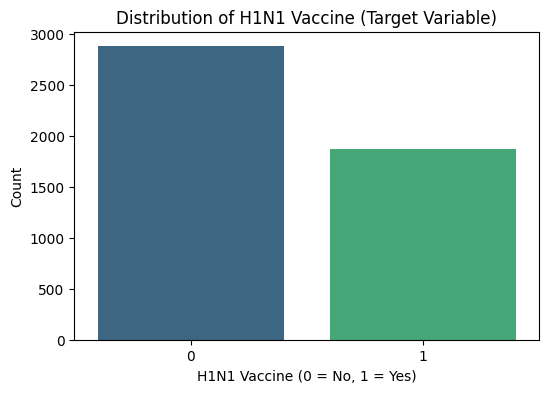

In [ ]:
# Distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='h1n1_vaccine', data=train_df, palette='viridis')
plt.title('Distribution of H1N1 Vaccine (Target Variable)')
plt.xlabel('H1N1 Vaccine (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

### 2. Distribution of Key Categorical Features

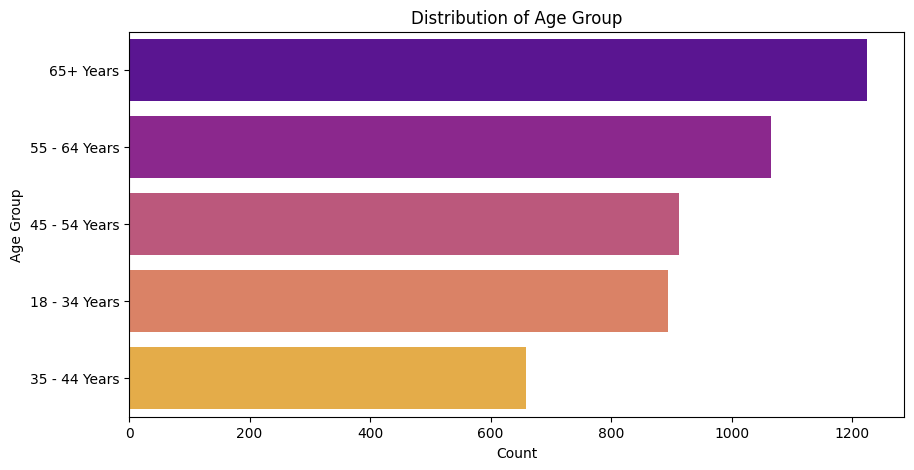

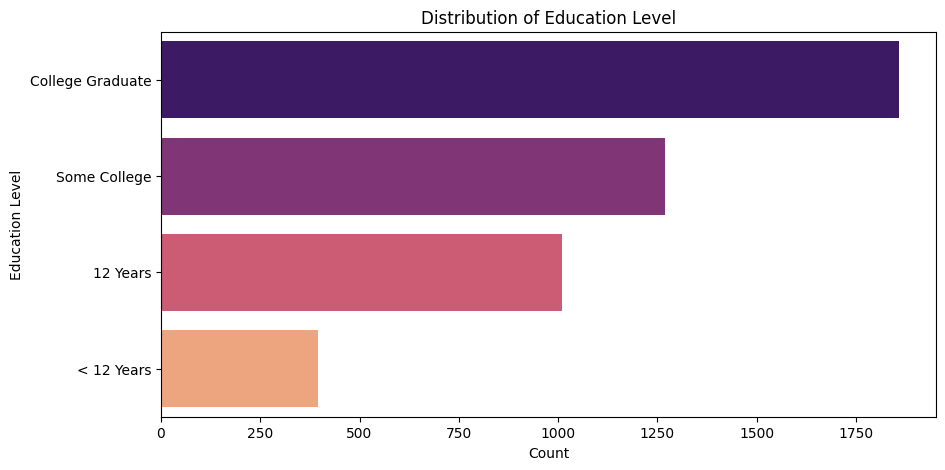

In [ ]:
# Distribution of 'age_group'
plt.figure(figsize=(10, 5))
sns.countplot(y='age_group', data=train_df, palette='plasma', order=train_df['age_group'].value_counts().index)
plt.title('Distribution of Age Group')
plt.xlabel('Count')
plt.ylabel('Age Group')
plt.show()

# Distribution of 'education'
plt.figure(figsize=(10, 5))
sns.countplot(y='education', data=train_df, palette='magma', order=train_df['education'].value_counts().index)
plt.title('Distribution of Education Level')
plt.xlabel('Count')
plt.ylabel('Education Level')
plt.show()

### 3. Distribution of Key Ordinal/Numerical Features

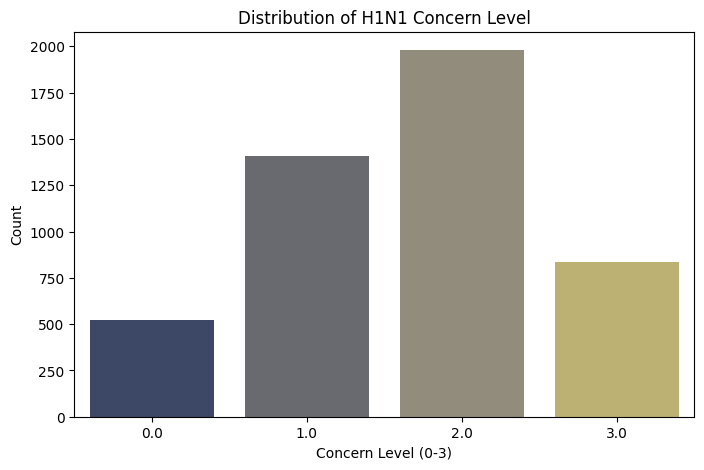

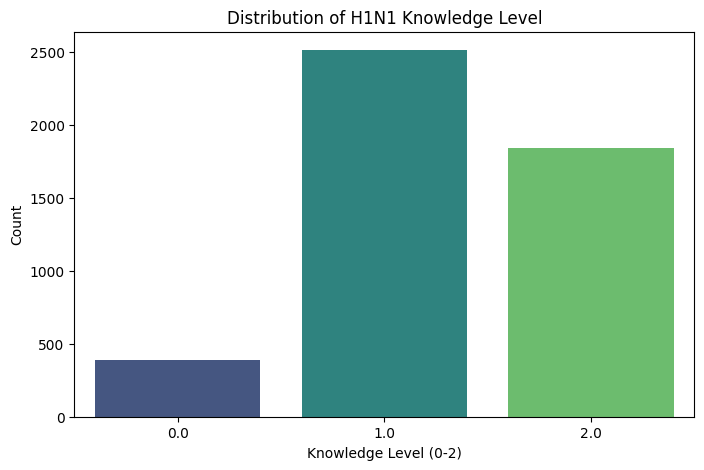

In [ ]:
# Distribution of 'h1n1_concern'
plt.figure(figsize=(8, 5))
sns.countplot(x='h1n1_concern', data=train_df, palette='cividis')
plt.title('Distribution of H1N1 Concern Level')
plt.xlabel('Concern Level (0-3)')
plt.ylabel('Count')
plt.show()

# Distribution of 'h1n1_knowledge'
plt.figure(figsize=(8, 5))
sns.countplot(x='h1n1_knowledge', data=train_df, palette='viridis')
plt.title('Distribution of H1N1 Knowledge Level')
plt.xlabel('Knowledge Level (0-2)')
plt.ylabel('Count')
plt.show()

### 4. Correlation Matrix of Numerical Features

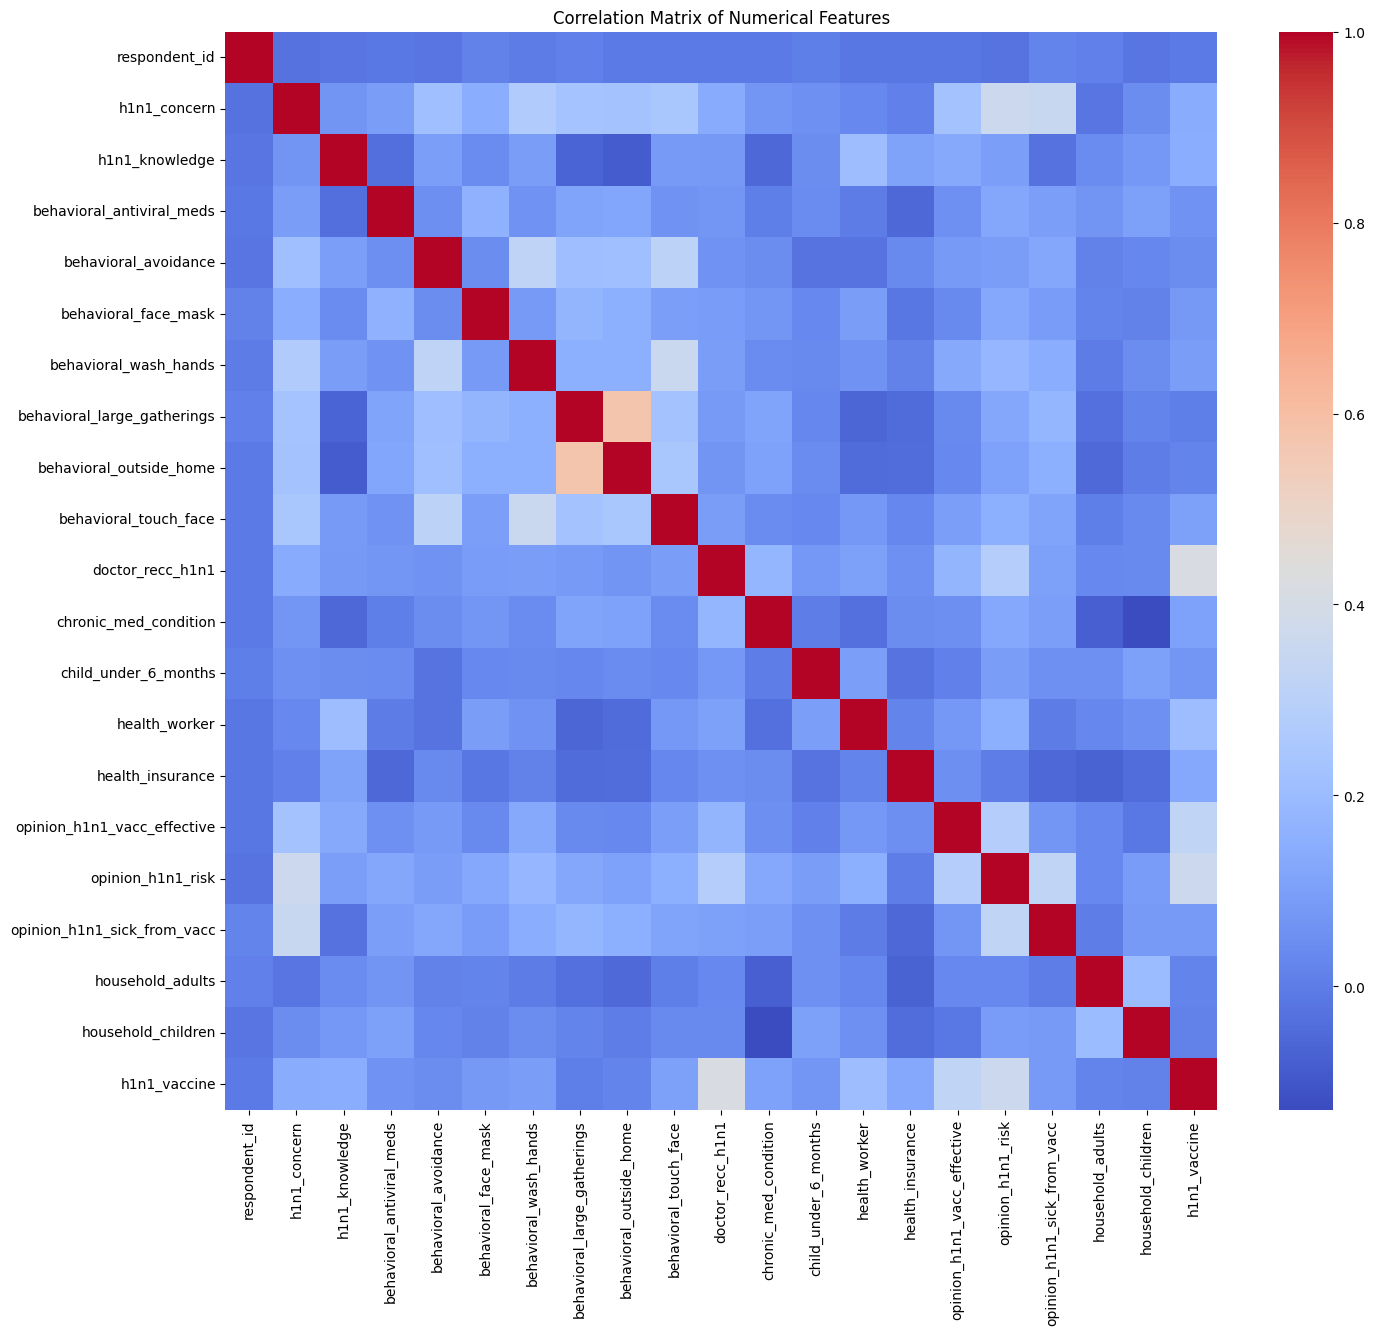

In [ ]:
# Select only numerical columns for correlation matrix
numerical_cols = train_df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = train_df[numerical_cols].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### 5. Relationship between Features and Target Variable (`h1n1_vaccine`)

Let's examine how the vaccination rate varies across different demographic and behavioral groups.

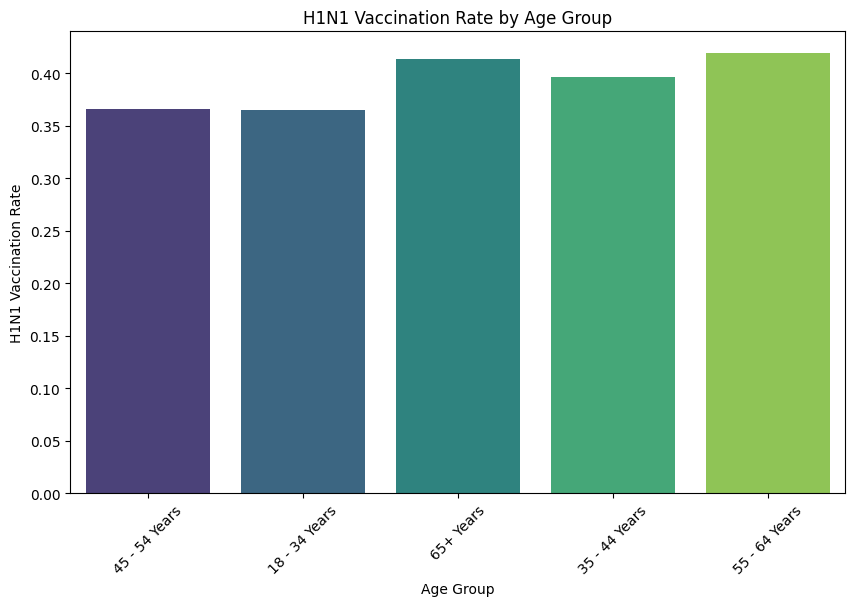

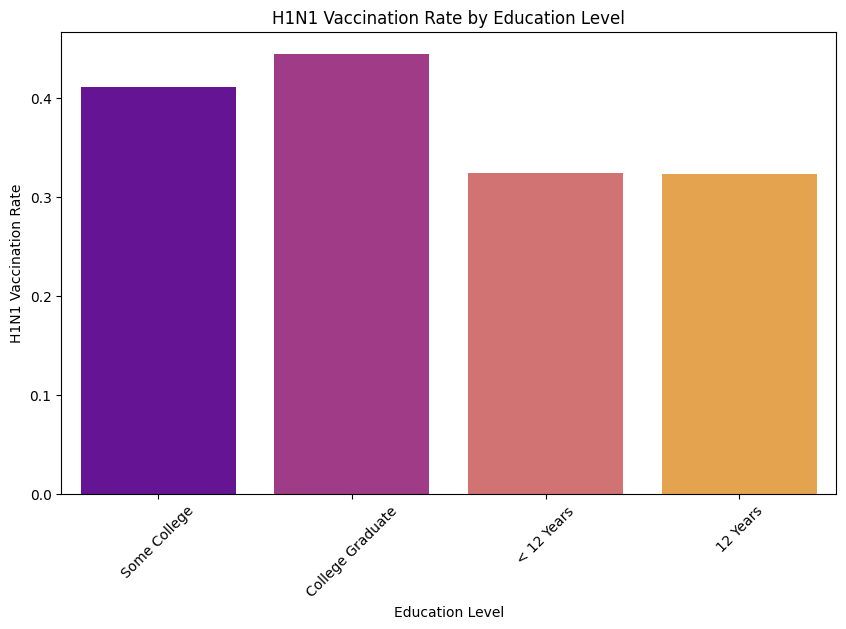

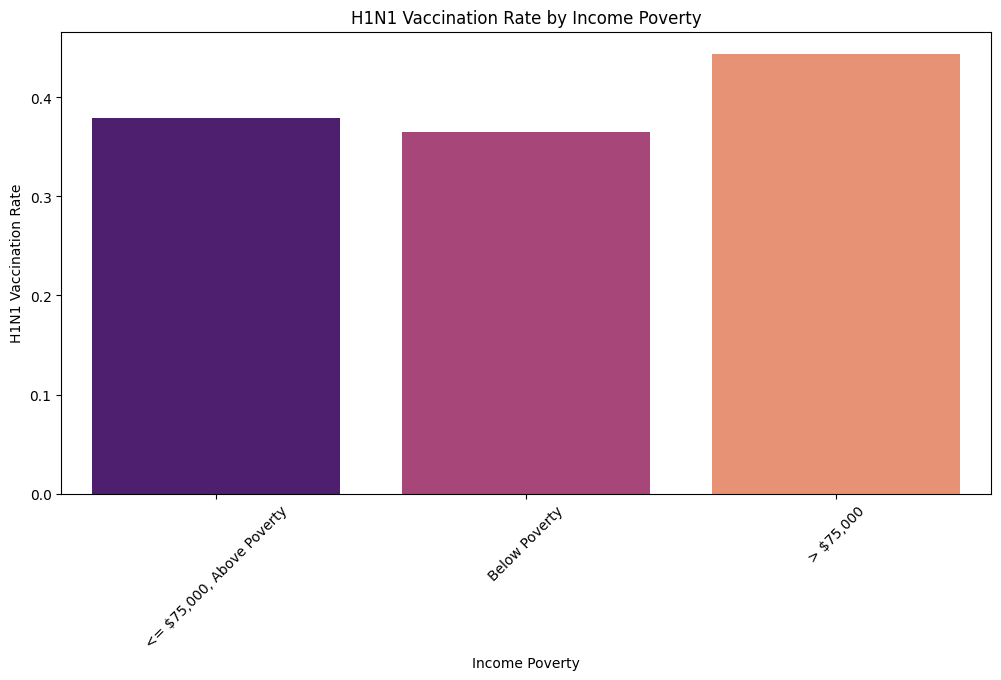

In [ ]:
# H1N1 Vaccine rate by Age Group
plt.figure(figsize=(10, 6))
sns.barplot(x='age_group', y='h1n1_vaccine', data=train_df, palette='viridis', ci=None)
plt.title('H1N1 Vaccination Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('H1N1 Vaccination Rate')
plt.xticks(rotation=45)
plt.show()

# H1N1 Vaccine rate by Education Level
plt.figure(figsize=(10, 6))
sns.barplot(x='education', y='h1n1_vaccine', data=train_df, palette='plasma', ci=None)
plt.title('H1N1 Vaccination Rate by Education Level')
plt.xlabel('Education Level')
plt.ylabel('H1N1 Vaccination Rate')
plt.xticks(rotation=45)
plt.show()

# H1N1 Vaccine rate by Income Poverty
plt.figure(figsize=(12, 6))
sns.barplot(x='income_poverty', y='h1n1_vaccine', data=train_df, palette='magma', ci=None)
plt.title('H1N1 Vaccination Rate by Income Poverty')
plt.xlabel('Income Poverty')
plt.ylabel('H1N1 Vaccination Rate')
plt.xticks(rotation=45)
plt.show()

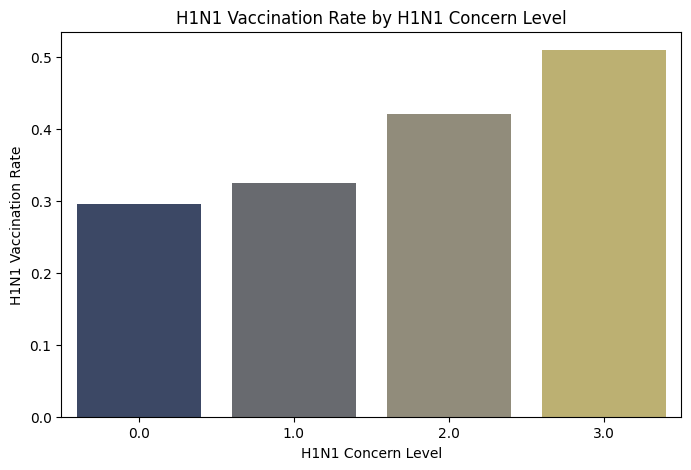

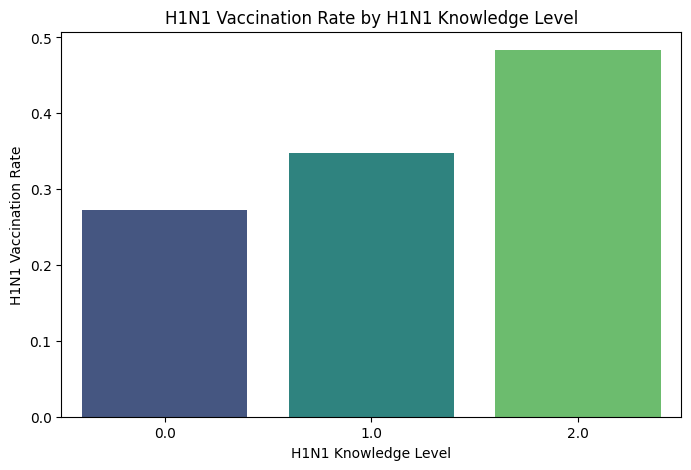

In [ ]:
# H1N1 Vaccine rate by H1N1 Concern Level
plt.figure(figsize=(8, 5))
sns.barplot(x='h1n1_concern', y='h1n1_vaccine', data=train_df, palette='cividis', ci=None)
plt.title('H1N1 Vaccination Rate by H1N1 Concern Level')
plt.xlabel('H1N1 Concern Level')
plt.ylabel('H1N1 Vaccination Rate')
plt.show()

# H1N1 Vaccine rate by H1N1 Knowledge Level
plt.figure(figsize=(8, 5))
sns.barplot(x='h1n1_knowledge', y='h1n1_vaccine', data=train_df, palette='viridis', ci=None)
plt.title('H1N1 Vaccination Rate by H1N1 Knowledge Level')
plt.xlabel('H1N1 Knowledge Level')
plt.ylabel('H1N1 Vaccination Rate')
plt.show()